# 01 - Exploratory Data Analysis

This notebook starts the AI-based short-term electricity load forecasting project using the UCI ElectricityLoadDiagrams20112014 dataset.

Main goals:

- Load and inspect the 15-minute electricity load dataset.
- Select a representative meter/client.
- Visualize daily and weekly load patterns.
- Prepare the project for 1-hour and 24-hour ahead forecasting.

Forecasting definition:

- 1-hour horizon = 4 future 15-minute steps.
- 24-hour horizon = 96 future 15-minute steps.
- Input features include historical load, time features, weekend/holiday flags, lag features, and rolling features.
- Output is the future electricity load value.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

from src.config import RAW_DATA_DIR, RAW_DATA_FILENAME, FIGURES_DIR, TABLES_DIR, ONE_HOUR_CONFIG, TWENTY_FOUR_HOUR_CONFIG
from src.data_loader import load_electricity_load_data
from src.features import add_time_features

sns.set_theme(style="whitegrid")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

raw_path = RAW_DATA_DIR / RAW_DATA_FILENAME
raw_path

WindowsPath('C:/Users/clt/Documents/Codex/2026-08-03/lie/work/energy-load-forecasting/data/raw/LD2011_2014.txt')

## 1. Load Dataset

Put the raw dataset file at `data/raw/LD2011_2014.txt`. If the file does not exist yet, download it from the UCI dataset page and place it there.

In [2]:
if not raw_path.exists():
    raise FileNotFoundError(
        f"Dataset not found: {raw_path}\n"
        "Download UCI ElectricityLoadDiagrams20112014 and place LD2011_2014.txt under data/raw/."
    )

df = load_electricity_load_data(raw_path)
print(df.shape)
df.head()

(140256, 370)


,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,MT_010,...,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
timestamp,,,,,,,,,,,,,,,,,,,,,
2011-01-01 00:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 00:30:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 00:45:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 01:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 01:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
df.info()
df.describe().T.head()

<class 'pandas.DataFrame'>
DatetimeIndex: 140256 entries, 2011-01-01 00:15:00 to 2015-01-01 00:00:00
Columns: 370 entries, MT_001 to MT_370
dtypes: float64(370)
memory usage: 397.0 MB


,count,mean,std,min,25%,50%,75%,max
MT_001,140256.0,3.970785,5.983965,0.0,0.000000,1.269036,2.538071,48.223350
MT_002,140256.0,20.768480,13.272415,0.0,2.844950,24.893314,29.871977,115.220484
MT_003,140256.0,2.918308,11.014456,0.0,0.000000,1.737619,1.737619,151.172893
MT_004,140256.0,82.184490,58.248392,0.0,36.585366,87.398374,115.853659,321.138211
MT_005,140256.0,37.240309,26.461327,0.0,15.853659,39.024390,54.878049,150.000000


## 2. Select A Representative Meter

The dataset contains many clients/meters. Because UCI reports no missing values, missing-value coverage cannot distinguish a useful meter. We keep meters with load above zero in at least 99% of intervals, then choose the meter whose mean load is closest to the median of that group. This produces a complete but not unusually large representative series.

In [4]:
non_zero_ratio = df.gt(0).mean()
meter_stats = pd.DataFrame({
    "non_zero_ratio": non_zero_ratio,
    "mean_load": df.mean(),
    "std_load": df.std(),
})
eligible_meters = meter_stats[meter_stats["non_zero_ratio"] >= 0.99].copy()
median_mean_load = eligible_meters["mean_load"].median()
eligible_meters["distance_to_median"] = (eligible_meters["mean_load"] - median_mean_load).abs()
candidate_meters = eligible_meters.sort_values("distance_to_median").head(10)
candidate_meters

,non_zero_ratio,mean_load,std_load,distance_to_median
MT_252,1.000000,232.634185,82.161861,5.048176
MT_309,1.000000,222.537833,56.796387,5.048176
MT_331,0.999586,221.827103,80.838968,5.758905
MT_313,0.999316,237.951894,79.380430,10.365886
MT_217,0.999879,214.454970,88.063681,13.131038
MT_202,0.999879,242.393145,72.339054,14.807136
MT_329,1.000000,212.729004,57.479582,14.857004
MT_206,0.999886,209.215103,71.196312,18.370905
MT_171,1.000000,246.217773,63.732763,18.631764
MT_198,0.999829,246.908219,92.441763,19.322211


In [5]:
meter_id = candidate_meters.index[0]
series = df[meter_id].dropna().rename("load").to_frame()
series.head(), series.tail(), series.shape

(                           load
 timestamp                      
 2011-01-01 00:15:00  130.843558
 2011-01-01 00:30:00  115.490798
 2011-01-01 00:45:00  113.957055
 2011-01-01 01:00:00  121.641104
 2011-01-01 01:15:00  123.174847,
                            load
 timestamp                      
 2014-12-31 23:00:00  103.220859
 2014-12-31 23:15:00   97.070552
 2014-12-31 23:30:00  103.220859
 2014-12-31 23:45:00   98.604294
 2015-01-01 00:00:00  101.687117,
 (140256, 1))

## 3. Time Coverage And Basic Patterns

In [6]:
print("Selected meter:", meter_id)
print("Start:", series.index.min())
print("End:", series.index.max())
print("Rows:", len(series))
print("1-hour horizon steps:", ONE_HOUR_CONFIG.target_horizon_steps)
print("24-hour horizon steps:", TWENTY_FOUR_HOUR_CONFIG.target_horizon_steps)

Selected meter: MT_252
Start: 2011-01-01 00:15:00
End: 2015-01-01 00:00:00
Rows: 140256
1-hour horizon steps: 4
24-hour horizon steps: 96


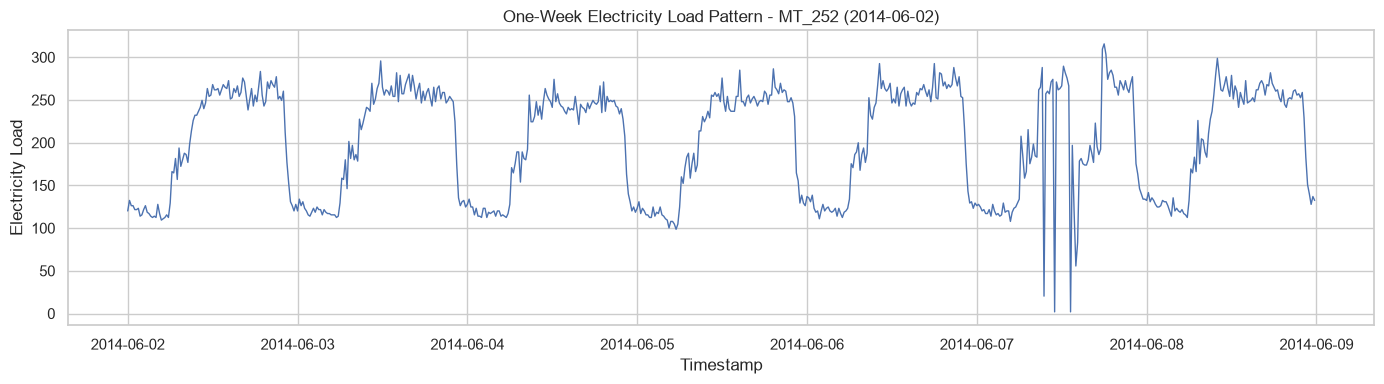

In [7]:
sample_start = pd.Timestamp("2014-06-02 00:00:00")
sample_end = sample_start + pd.Timedelta(days=7) - pd.Timedelta(minutes=15)
sample_week = series.loc[sample_start:sample_end]

plt.figure(figsize=(14, 4))
plt.plot(sample_week.index, sample_week["load"], linewidth=1)
plt.title(f"One-Week Electricity Load Pattern - {meter_id} ({sample_start.date()})")
plt.xlabel("Timestamp")
plt.ylabel("Electricity Load")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "week_load_pattern.png", dpi=160)
plt.show()

## 4. Average Daily Pattern

This helps identify peak and off-peak periods, which are important for smart grid dispatching and building energy management.

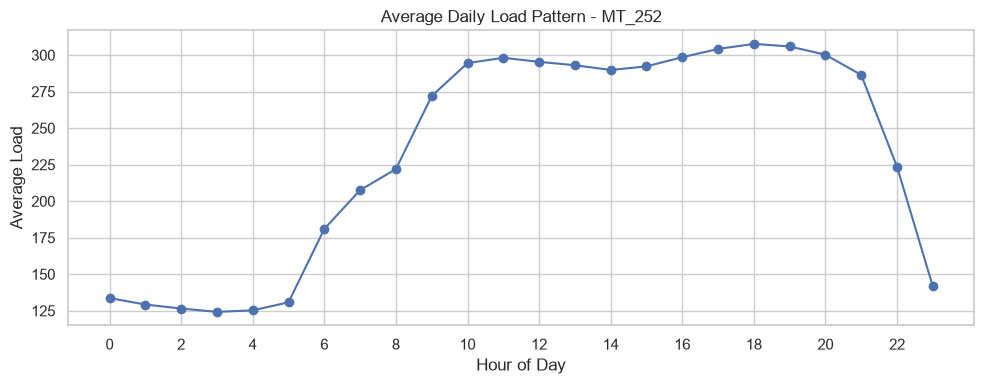

In [8]:
feature_df = add_time_features(series)
daily_pattern = feature_df.groupby("hour")["load"].mean()

plt.figure(figsize=(10, 4))
daily_pattern.plot(marker="o")
plt.title(f"Average Daily Load Pattern - {meter_id}")
plt.xlabel("Hour of Day")
plt.ylabel("Average Load")
plt.xticks(range(0, 24, 2))
plt.tight_layout()
plt.savefig(FIGURES_DIR / "average_daily_pattern.png", dpi=160)
plt.show()

## 5. Weekday vs Weekend Pattern

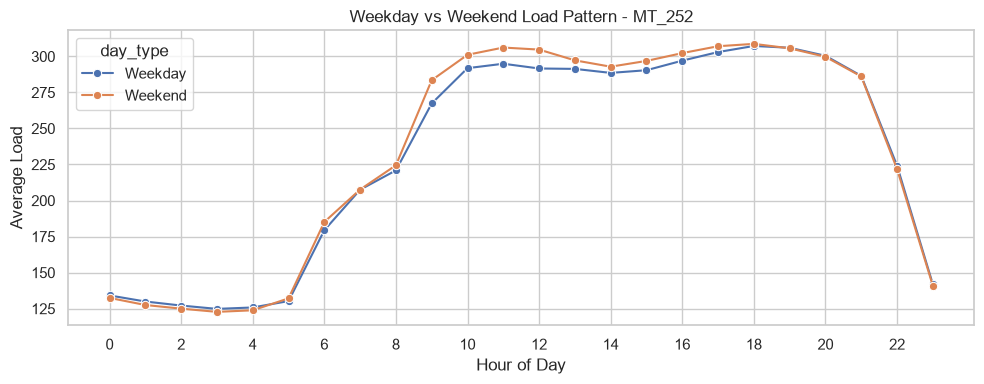

In [9]:
weekday_pattern = feature_df.groupby(["is_weekend", "hour"])["load"].mean().reset_index()
weekday_pattern["day_type"] = weekday_pattern["is_weekend"].map({0: "Weekday", 1: "Weekend"})

plt.figure(figsize=(10, 4))
sns.lineplot(data=weekday_pattern, x="hour", y="load", hue="day_type", marker="o")
plt.title(f"Weekday vs Weekend Load Pattern - {meter_id}")
plt.xlabel("Hour of Day")
plt.ylabel("Average Load")
plt.xticks(range(0, 24, 2))
plt.tight_layout()
plt.savefig(FIGURES_DIR / "weekday_vs_weekend_pattern.png", dpi=160)
plt.show()

## 6. Quantitative Summary

These values turn the charts into model-design decisions. High 1-hour and 24-hour autocorrelation supports using lag features, while the weekday/weekend gap supports calendar features.

In [10]:
peak_hour = int(daily_pattern.idxmax())
off_peak_hour = int(daily_pattern.idxmin())
weekday_mean = feature_df.loc[feature_df["is_weekend"] == 0, "load"].mean()
weekend_mean = feature_df.loc[feature_df["is_weekend"] == 1, "load"].mean()
weekend_difference_pct = (weekend_mean / weekday_mean - 1) * 100

eda_summary = pd.DataFrame([{
    "meter_id": meter_id,
    "start": series.index.min(),
    "end": series.index.max(),
    "rows": len(series),
    "mean_load_kw": series["load"].mean(),
    "std_load_kw": series["load"].std(),
    "min_load_kw": series["load"].min(),
    "max_load_kw": series["load"].max(),
    "peak_hour": peak_hour,
    "off_peak_hour": off_peak_hour,
    "weekday_mean_kw": weekday_mean,
    "weekend_mean_kw": weekend_mean,
    "weekend_difference_pct": weekend_difference_pct,
    "lag_1h_autocorrelation": series["load"].autocorr(lag=4),
    "lag_24h_autocorrelation": series["load"].autocorr(lag=96),
}])
eda_summary.to_csv(TABLES_DIR / "eda_summary.csv", index=False)
eda_summary.T

,0
meter_id,MT_252
start,2011-01-01 00:15:00
end,2015-01-01 00:00:00
rows,140256
mean_load_kw,232.634185
std_load_kw,82.161861
min_load_kw,1.917178
max_load_kw,467.944785
peak_hour,18
off_peak_hour,3


## 7. EDA Notes

Write your observations here after running the notebook.

Example structure:

1. The selected meter shows clear daily seasonality.
2. Peak load usually appears around ...
3. Weekend usage is higher/lower than weekday usage during ...
4. These patterns suggest that lag features and calendar features should be useful for forecasting.
5. The forecasting result can support smart grid dispatching, building energy management, and storage scheduling.